In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Pokemon.csv")



In [2]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [3]:
df_features = df[["HP",	"Attack",	"Defense",	"Sp. Atk",	"Sp. Def", "Speed"]]
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)

In [4]:
df["Type 1"].unique().size

18

In [5]:
k = 3 # - Если мы учитываем только характеристики, то можно либо характеризовать это как 3 уровня эволюции
#либо просто некий топ
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(df_scaled)
# Предсказанные кластеры
labels = kmeans.labels_
# Центроиды
centroids = kmeans.cluster_centers_

In [6]:
print("Кластеры для объектов:\n", labels)
print("Координаты центроидов:\n", centroids)

Кластеры для объектов:
 [0 0 2 2 0 1 1 2 1 0 0 2 2 0 0 1 0 0 1 1 0 0 1 1 0 1 0 1 0 1 0 1 0 2 0 0 2
 0 0 1 0 2 0 1 0 2 0 1 0 0 2 0 0 0 1 0 1 0 1 0 1 0 1 0 1 0 0 2 0 1 1 1 0 0
 2 0 0 1 0 1 0 0 2 1 1 0 2 2 0 1 0 0 1 0 2 0 2 0 2 0 1 1 1 0 0 2 0 2 0 1 0
 2 0 2 1 2 0 0 2 0 2 2 0 2 2 0 1 0 1 0 1 1 1 1 1 1 2 2 1 0 2 2 2 0 0 2 1 2
 0 0 2 0 2 1 1 2 2 1 2 0 1 2 1 2 1 2 0 0 2 0 1 1 0 0 2 0 1 0 1 0 1 0 0 1 0
 2 0 0 0 0 0 0 1 0 0 2 2 2 0 2 2 2 0 0 1 0 0 2 1 0 2 1 2 1 2 1 0 2 1 0 2 2
 1 2 2 0 2 1 2 2 2 2 2 1 0 2 0 2 0 2 0 0 2 0 2 2 0 1 1 2 0 2 2 1 0 0 2 0 0
 0 1 2 1 2 2 0 0 2 2 2 2 2 0 1 1 1 0 0 1 1 0 0 2 2 0 1 0 1 0 0 0 0 0 0 0 2
 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 0 1 2 0 1 0 0 0 2 0 2 0 0 0 0 0 2 0 2 0 2 2
 2 0 1 1 0 1 1 1 1 1 1 1 0 2 0 1 1 1 2 0 2 2 2 0 1 0 0 0 1 0 1 0 2 2 1 1 1
 1 0 2 0 2 0 2 0 2 0 2 0 2 1 2 0 1 2 0 2 2 1 1 1 0 0 1 1 0 0 2 0 2 2 2 0 0
 0 1 2 0 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 1 1 2 1 0 0 2 0 1 1 0 0 2 0 0 1
 0 1 0 0 0 0 2 0 1 0 2 0 2 0 2 2 2 1 0 2 1 0 1 0 1 0 2 1 0 1 0 1 1 1 1 0 1
 

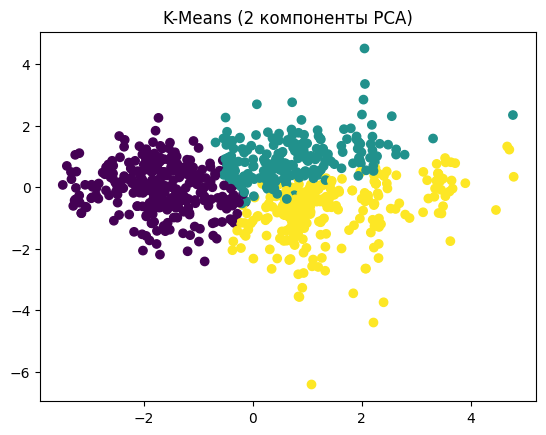

In [7]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)
plt.scatter(df_pca[:,0], df_pca[:,1], c=labels)
plt.title("K-Means (2 компоненты PCA)")
plt.show()

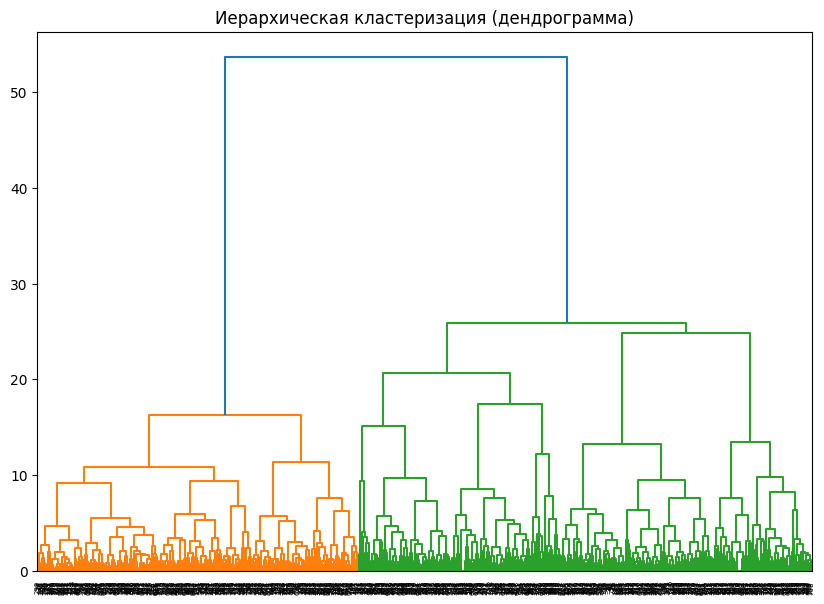

[ 2  4 10 10  1 15 18 18 17  5  4 10 10  3  3  4  3  3 13 14  1  1 13 18
  1 13  1 13  1 13  1 14  1  4  2  4 10  1  4 13  2 10  2 15  3  7  1 13
  2  4 10  1  4  2 15  1 13  1 14  1 10  1 13  1 18  1  1 10 15 15 15 18
  3  4  8  1  4  9  2 10  5  5  8 13 13  3  9 11  5 10  4  1 13  2 10  3
  8  5 11 15 15 15 18 11  2 10  1 13  1 15  5  9  5  5 13 13  9  5 10  5
  8  6 10  8 16  5 10  1 10  1 15 15 13 15 14 14 13 16 13  1 13 16  9  2
  2  9 15 13  4  5 10  5 13 14 14  7 10 18 18  1 13 16 18 17 17 16  5  4
 10  1 15 18  1  4 10  2 13  2 10  2  2  3  4 14  4  9  1  2  3  5  5  1
 14  2  4 10 10 10  2  9  5 10  2  2 15  1  3  4 15  3  9 15 10 15  9 15
  1  7 14  5 11  9 13 11 11  1  8 13 13 16 12 13 16 13  1  8  2  5  1  8
  5  1  9  1 15 13  1 14 18 10  3  8 10 14  2  3 13  2 15 15  8  6 18 16
 10  1  4 16 16 10 10 16  1 15 18 18  1  4 18 18  1  4  8 16  3 13  1 13
  3  3  4  3  4  2  2 10  3  4  9  1 14  1  4  3  1 15 17  2  4  2 13  1
 13 16  5 14  1  3  4  9  3  7  3  5  1  4  4 12  4

In [8]:
import scipy.cluster.hierarchy as sch
# linkage: метод объединения, например "ward" (минимизация роста внутрикластерной суммы квадратов)
Z = sch.linkage(df_scaled, method='ward')
# Построение дендрограммы
plt.figure(figsize=(10, 7))
dn = sch.dendrogram(Z)
plt.title("Иерархическая кластеризация (дендрограмма)")
plt.show()
# Можно выделить 18 классов - типы покемонов. Не факт что ни попадут, но такую задачу поставить можно
clusters = fcluster(Z, t=18, criterion='maxclust')
print(clusters)

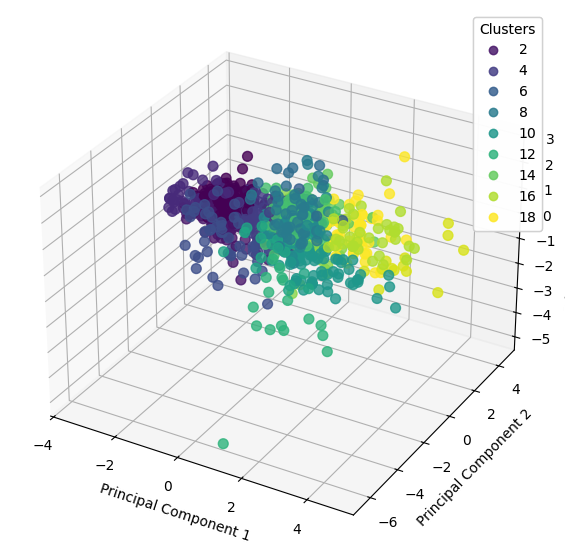

In [9]:
# Снижение размерности до 3D с помощью PCA
pca = PCA(n_components=3)
data_3d = pca.fit_transform(df_scaled)

# Создание 3D-графика
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(
    data_3d[:, 0],  # Первая главная компонента
    data_3d[:, 1],  # Вторая главная компонента
    data_3d[:, 2],  # Третья главная компонента
    c=clusters,     # Цвета точек соответствуют кластерам
    cmap='viridis', # Цветовая карта
    s=50,           # Размер точек
    alpha=0.8       # Прозрачность
)

# Добавление подписей осей
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Добавление легенды
legend = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend)

# Показать график
plt.show()